# Computer and Robot Vision - Particle Filter

Here we import the dependencies:

In [47]:
import numpy as np
from scipy.stats import multivariate_normal
from typing import NamedTuple
import matplotlib.pyplot as plt
from IPython import display

# serve per montare Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fill out the following information:

In [48]:
name = "Oleksandra"
surname = "Golub"
mat = "856706"

In [49]:
print(name, " ", surname, " ", mat, " ")

Oleksandra   Golub   856706  


## Answer the questions

❓ **R1. build sampling method: quale metodo di resampling avete utilizzato?**


E' stato utilizzato un metodo di resampling sistematico (systematic resampling), che appartiene alla famiglia dei metodi di resampling a bassa varianza.

In questo approccio, dopo aver normalizzato i pesi delle particelle e costruito la funzione di distribuzione cumulativa, si estrae un singolo punto iniziale casuale nell’intervallo [0, 1/N] e successivamente si selezionano le particelle usando punti equispaziati.

Questo metodo consente di ridurre la varianza introdotta dal resampling rispetto al resampling multinomiale classico, evitando una duplicazione eccessiva delle stesse particelle e migliorando la stabilità numerica del filtro, soprattutto in presenza di un numero elevato di particelle.

❓ **R2. in cosa consiste il problema noto come 'particle deprivation'?**


Questo tipo di problema si verifica quando, a seguito di ripetuti cicli di weighting e resampling, la popolazione di particelle perde progressivamente diversità.

In particolare, poche particelle con peso elevato vengono replicate molte volte, mentre le altre vengono eliminate, causando un collasso del belief su una regione molto ristretta dello spazio di stato.

Questo fenomeno è critico in presenza di modelli di misura molto selettivi, rumore di misura ridotto o belief multimodali, perché il filtro perde la capacità di rappresentare correttamente più ipotesi alternative sullo stato del sistema.


❓ **R3. OPZIONALE se hai avuto problemi di 'particle deprivation', prova a risolverli utilizzando i metodi descritti a lezione (adattando il codice per risolvere questo problema si otterrà un voto più alto). Descrivi qui la tecnica che hai utilizzato.**

Per mitigare il problema della particle deprivation è stata utilizzata la tecnica di roughening.

Questa tecnica consiste nell’aggiungere un rumore controllato alle particelle immediatamente dopo il resampling, in modo da reintrodurre diversità nella popolazione.

Il rumore viene scalato in funzione dell’estensione del particle set nello spazio di stato e del numero di particelle, secondo una legge che riduce l’intensità del rumore all’aumentare di
N.

In questo modo si evita che le particelle collassino tutte esattamente sugli stessi valori e si preserva la capacità del filtro di esplorare regioni alternative dello spazio di stato, mantenendo attiva la rappresentazione di belief multimodali.

❓ **R4. il numero delle particelle è fisso nella implementazione standard. E' possibile rendere variabile il numero di particelle? Descrivere vantaggi e svantaggi.**

Nella forma standard del particle filter il numero di particelle è fisso, ma è possibile renderlo variabile nel tempo.

Un numero variabile di particelle permette di adattare la complessità computazionale del filtro allo stato del belief: quando il belief è concentrato e unimodale è possibile utilizzare meno particelle, mentre in situazioni di forte incertezza o multimodalità è utile aumentare il numero di particelle per rappresentare correttamente più ipotesi.

Il principale vantaggio è quindi un migliore compromesso tra accuratezza e costo computazionale.

Lo svantaggio è l’aumento della complessità dell’algoritmo e la necessità di definire criteri affidabili per decidere quando e come variare il numero di particelle, evitando instabilità o oscillazioni inutili.

❓ **R5. OPZIONALE prova ad introdurre una tecnica per rendere variabile il numero di particelle (adattando il codice per introdurre questa tecnica si otterrà un voto più alto). Descrivi qui la tecnica che hai utilizzato.**

Una possibile tecnica per rendere variabile il numero di particelle si basa sull’utilizzo della Effective Sample Size (ESS).

Monitorando l’ESS è possibile stimare quanto il particle set sia degenerato: valori bassi indicano che poche particelle dominano il belief, mentre valori elevati indicano una distribuzione più uniforme.

In una versione adattativa del particle filter, l’ESS può essere utilizzata non solo per decidere se effettuare il resampling, ma anche per aumentare o ridurre il numero di particelle.

Ad esempio, quando l’ESS scende sotto una certa soglia si può incrementare il numero di particelle per migliorare la rappresentazione del belief, mentre quando l’ESS è elevata si può ridurre il numero di particelle per risparmiare risorse computazionali, mantenendo comunque una stima affidabile dello stato.

# Parameters configuration

Here we setup a dataclass representing the robot and camera configuration and one representing a particle in the particle filter

In [50]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

class Scene(NamedTuple):
    baseline : float
    focal_length : float
    camera_height : float
    p2p_distance : float
    length : float
    width : float

class Particle(NamedTuple):
    state : np.ndarray

    @property
    def x(self):
        return self.state[0]
    @x.setter
    def x(self, value):
        self.state[0] = value

    @property
    def y(self):
        return self.state[1]
    @y.setter
    def y(self, value):
        self.state[1] = value

    @property
    def theta(self):
        return self.state[2]
    @theta.setter
    def theta(self, value):
        self.state[2] = value

    # for interoperability with NumPy
    @property
    def __array_interface__(self):
        return self.state.__array_interface__

    def __array__(self):
        return self.state.__array__()

    def __array_wrap__(self, out_arr, context=None, return_scalar=False):
        return Particle(out_arr)

# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

In [51]:
# ⬇️⬇️⬇️⬇️⬇️ COMPLETE THE CODE ⬇️⬇️⬇️⬇️⬇️

# Complete with the parameters of the scene
scene = Scene(
    baseline = 0.5,     # [m], the distance between the contact points of the wheels (0.5m)
    focal_length = 600,  # [pixel], the focal length of the camera (600pix)
    camera_height = 10, # [m], the distance between the camera and the world plane (10m)
    p2p_distance = 0.6,  # [m], the distance between the two observed points on the robot (0.6m forward)
    length = 40,      # [m], world length
    width  = 40        # [m], world width
)
## la scelta 40x40 di length x width e' la scelta del dominio
## serve per stabilire lo spazio abbastanza grande da contenere traiettorie plausibili

# Complete with the number of initialize the filter with random samples as a list of particle objects
number_of_particles = 2000
particle_set_a = [
    Particle(state = np.array([
        np.random.uniform(-scene.length/2, scene.length/2),   ## x random in [-20, 20]
        np.random.uniform(-scene.width/2, scene.width/2),     ## y random in [-20, 20]
        np.random.uniform(-np.pi, np.pi)                      ## theta random in [-pi, +pi]
    ])) for _ in range(number_of_particles)
]

# ⬆️⬆️⬆️⬆️⬆️ COMPLETE THE CODE ⬆️⬆️⬆️⬆️⬆️

In [52]:
## README: questo codice serviva a me per usare il file simulated_data4t.txt che ho caricato sul mio Google Drive
## nella consegna l'ho commentato, ma nel caso vi servisse per testare il codice, basta de-commentare questo blocco di codice
## e creare in un vostro Google Drive la cartella assignment_2_robot_and_computer_vision + mettere dentro il file di simulated_data4t.txt
## alla fine si commenta nel blocco sotto la riga di data = np.loadtxt('simulated_data4t.txt', delimiter=';')

## percorso del file su Google Drive
#path = '/content/drive/MyDrive/assignment_2_robot_and_computer_vision/simulated_data4t.txt'

## caricamento dei dati
#data = np.loadtxt(path, delimiter=';')

In [53]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

data = np.loadtxt('simulated_data4t.txt', delimiter=';')
odometry = np.array(data[:, 2:4])
camera_readings1 = np.array(data[:, 10:14])
camera_readings2 = np.array(data[:, 14:18])
camera_readings3 = np.array(data[:, 18:22])
camera_readings4 = np.array(data[:, 22:26])

steps = data.shape[0]
particle_set_b = []
particle_weights = []

# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

# Particle filter functions

Here we define the functions dictating how prediction and resampling steps are performed

In [54]:
# ⬇️⬇️⬇️⬇️⬇️ COMPLETE THE CODE ⬇️⬇️⬇️⬇️⬇️

def predict_particle(particle, odometry, scene) -> Particle:
    # Compute the next state prediction.
    # Be sure to return a new Particle with state set as an np.ndarray of shape (3,).

  	## si estraie lo stato corrente
    x = particle.x
    y = particle.y
    theta = particle.theta

    ## si estraie l'odometria
    sdx = odometry[0]  # arco ruota destra
    ssx = odometry[1]  # arco ruota sinistra

    ## si aggiunge il rumore (motion noise) che serve per mantenere la diversita'
    ## senza il rumore, tutte le particelle collasserebbero nello stesso punto
    sigma_motion = 0.02  # 2cm di rumore standard
    sdx_noisy = sdx + np.random.normal(0, sigma_motion)
    ssx_noisy = ssx + np.random.normal(0, sigma_motion)

    ## caso del movimento rettilineo (ruote girano quasi uguale)
    if np.abs(ssx_noisy - sdx_noisy) < 1e-6:
        ## movimento dritto
        delta_s = (ssx_noisy + sdx_noisy) / 2.0

        x_t = x + delta_s * np.cos(theta)
        y_t = y + delta_s * np.sin(theta)
        a_t = theta  # orientamento non cambia

    else:
        ## caso generale del movimento curvilineo
        delta_theta = (ssx_noisy - sdx_noisy) / scene.baseline
        d = sdx_noisy * scene.baseline / (ssx_noisy - sdx_noisy)

        x_t = x - d * np.sin(theta) + d * np.sin(theta + delta_theta)
        y_t = y + d * np.cos(theta) - d * np.cos(theta + delta_theta)
        a_t = theta + delta_theta

        ## si normalizza l'angolo in [-pi, pi]
        a_t = np.arctan2(np.sin(a_t), np.cos(a_t))

    # si crea e si ritorna la nuova particella
    pred = Particle(state = np.array([x_t, y_t, a_t]))
    return pred



def predict_camera_reading(predicted_state, scene):
    # Compute the predicted camera reading.
    # Be sure to return an np.ndarray of shape (4,) and of form [u1, v1, u2, v2].

    x = predicted_state.x
    y = predicted_state.y
    theta = predicted_state.theta

    ## punto P1: origine del robot nel mondo
    u1 = scene.focal_length * x / scene.camera_height
    v1 = -scene.focal_length * y / scene.camera_height

    ## punto P2: a distanza d lungo l'asse x del robot
    ## coordinate mondo di P2:
    P2_x = x + scene.p2p_distance * np.cos(theta)
    P2_y = y + scene.p2p_distance * np.sin(theta)

    u2 = scene.focal_length * P2_x / scene.camera_height
    v2 = -scene.focal_length * P2_y / scene.camera_height

    return np.array([u1, v1, u2, v2])



def weight_particle(particle : Particle, scene : Scene, camera_readings):
    # Compute the weight of one Particle.

    ## si calcola la misura attesa per questa particella
    predicted_reading = predict_camera_reading(particle, scene)

    ## varianza del rumore di misura
    sigma_measurement = 8.0

    ## la lista per i pesi di ciascuna uscita sensoriale
    weights_per_reading = []

    ## per ogni uscita sensoriale (1, 2, 3, 4)
    for i in range(4):
        camera_reading = camera_readings[i]

        ## siccome nel file con i dati simulati le misure assenti sono codificate
        ## come NaN, facciamo questo controllo sotto
        if np.any(np.isnan(camera_reading)):
            ## si imposta che la misura assente imlpica un contributo nullo
            weights_per_reading.append(0.0)
            continue

        ## si calcola l'errore di innovazione ovvero la differenza tra misura reale e attesa
        innovation = camera_reading - predicted_reading

        ## mahalanobis distance (normalizzata per la varianza)
        mahalanobis_dist = np.sum((innovation ** 2) / (sigma_measurement ** 2))

        ## likelihood ovvero la probabilità di osservare z dato x
        likelihood = np.exp(-0.5 * mahalanobis_dist)

        weights_per_reading.append(likelihood)

    ## strategia di fusione: mixture model
    ## usare max significa che se ci sono davvero due target indistinguibili,
    ## si aspetta che le particelle si dividano in due cluster e restino entrambe
    epsilon = 1e-12
    weight = epsilon + max(weights_per_reading)

    return weight



def resample_particle_set(particle_set, particle_weights, iteration):
    # Compute the new particle set.
    # Be sure to return a list of Particle objects.

    N = len(particle_set) # numero totale di particelle
    weights = np.array(particle_weights) # conversione dei pesi in array numpy

    ## se la somma dei pesi è nulla, il filtro è in una situazione di degenerazione numerica
    ## in questo caso si restituisce una copia del particle set corrente per evitare il collasso del filtro
    weights_sum = np.sum(weights)
    if weights_sum < 1e-300:
        print(f"Attenzione! Tutti i pesi sono impostati a zero all'iterazione {iteration}!")
        return [Particle(state=np.copy(p.state)) for p in particle_set]

    weights = weights / weights_sum # normalizzazione dei pesi


    ## calcolo dell'Effective Sample Size (ESS)
    ## da ricordare: un valore basso di ESS indica il fenomeno di particle deprivation!
    ESS = 1.0 / np.sum(weights ** 2) # fornisce una stima del numero di particelle
    threshold = N / 2.0 # soglia per decidere se effettuare il resampling

    ## se l'ESS è abbastanza alto, il resampling non si fa
    ## cio' serve per preservare la diversità delle particelle
    if ESS >= threshold:
        return [Particle(state=np.copy(p.state)) for p in particle_set]


    ## --- SYSTEMATIC RESAMPLING ---
    cdf = np.cumsum(weights)  # distribuzione cumulativa
    u0 = np.random.uniform(0, 1.0 / N) # estrazione di un punto iniziale casuale nell'intervallo [0, 1/N]

    # campionamento sistematico delle particelle
    resampled_particle_set = []
    j = 0
    for i in range(N):
        u = u0 + i / N
        while j < N and u > cdf[j]:
            j += 1
        if j >= N:
            j = N - 1
        # alla fine si crea una copia della particella selezionata
        resampled_particle_set.append(Particle(state=np.copy(particle_set[j].state)))


    ## --- ROUGHENING ---

    K = 0.2 # fattore di roughening

    ## conversione del particle set in array per calcolare i range
    particles_array = np.vstack([p.state for p in resampled_particle_set])

    ## calcolo dei range dello spazio di stato
    x_range = np.max(particles_array[:, 0]) - np.min(particles_array[:, 0])
    y_range = np.max(particles_array[:, 1]) - np.min(particles_array[:, 1])
    theta_range = np.pi

    ## il rumore viene scalato con N^(-1/3) per renderlo dipendente dal numero di particelle
    N_inv = N ** (-1.0 / 3.0)
    sigma_x = K * x_range * N_inv
    sigma_y = K * y_range * N_inv
    sigma_theta = K * theta_range * N_inv

    ## applicazione del rumore di roughening a ciascuna particella
    for p in resampled_particle_set:
        p.state[0] += np.random.normal(0, sigma_x)
        p.state[1] += np.random.normal(0, sigma_y)
        p.state[2] += np.random.normal(0, sigma_theta)

        ## normalizzazione dell'angolo nell'intervallo [-pi, pi]
        p.state[2] = np.arctan2(np.sin(p.state[2]), np.cos(p.state[2]))

    return resampled_particle_set

# ⬆️⬆️⬆️⬆️⬆️ COMPLETE THE CODE ⬆️⬆️⬆️⬆️⬆️

# Execution

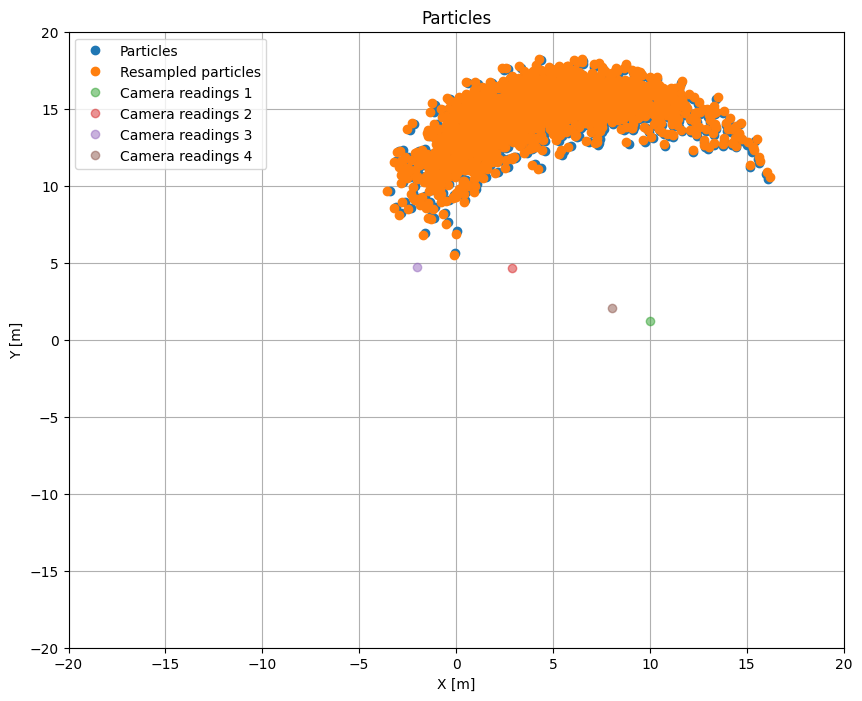

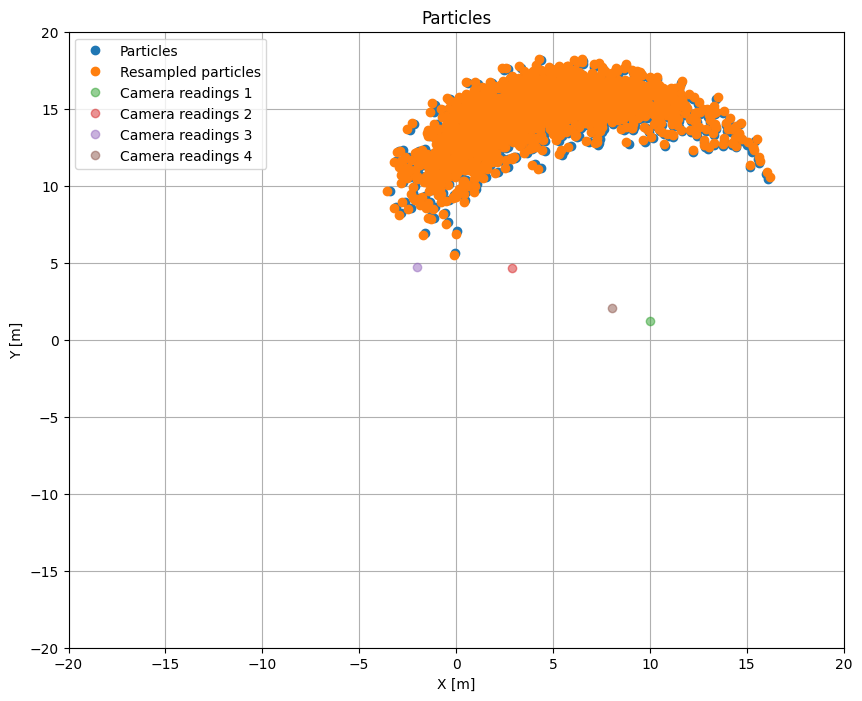

In [55]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

%matplotlib inline

trajectory = []
plt.figure(figsize=(10, 8))
for i in range(steps-1):
    particle_set_b = []
    particle_weights = []
    particles_coordinates = np.vstack(particle_set_a)
    for particle in particle_set_a:
        #prediction
        predicted_particle = predict_particle(particle, odometry[i], scene)
        particle_set_b.append(predicted_particle)
        #weigth
        particle_weights.append(weight_particle(
            predicted_particle,
            scene,
            np.vstack([
                camera_readings1[i],
                camera_readings2[i],
                camera_readings3[i],
                camera_readings4[i],
            ])
        ))

    trajectory.append(particle_set_b[np.argmax(particle_weights)])

    particle_set_a = resample_particle_set(particle_set_b, particle_weights, i)

    if len(particle_set_a) == 0:
        print(f"OUT OF PARTICLES")
        break

    display.clear_output(wait=True)
    plt.clf()
    plt.plot(particles_coordinates[:, 0], particles_coordinates[:, 1], 'o', label='Particles')
    resampled_particles_coordinates = np.vstack(particle_set_a)
    plt.plot(resampled_particles_coordinates[:, 0], resampled_particles_coordinates[:, 1], 'o', label='Resampled particles')

    x_cam = camera_readings1[i, 0] * scene.camera_height / scene.focal_length
    y_cam = -camera_readings1[i, 1] * scene.camera_height / scene.focal_length
    plt.plot(x_cam, y_cam, 'o', label='Camera readings 1', alpha=0.5)
    x_cam = camera_readings2[i, 0] * scene.camera_height / scene.focal_length
    y_cam = -camera_readings2[i, 1] * scene.camera_height / scene.focal_length
    plt.plot(x_cam, y_cam, 'o', label='Camera readings 2', alpha=0.5)
    x_cam = camera_readings3[i, 0] * scene.camera_height / scene.focal_length
    y_cam = -camera_readings3[i, 1] * scene.camera_height / scene.focal_length
    plt.plot(x_cam, y_cam, 'o', label='Camera readings 3', alpha=0.5)
    x_cam = camera_readings4[i, 0] * scene.camera_height / scene.focal_length
    y_cam = -camera_readings4[i, 1] * scene.camera_height / scene.focal_length
    plt.plot(x_cam, y_cam, 'o', label='Camera readings 4', alpha=0.5)

    plt.xlabel('X [m]')
    plt.ylabel('Y [m]')
    plt.xlim(-scene.width/2, scene.width/2)
    plt.ylim(-scene.length/2, scene.length/2)
    plt.legend()
    plt.title('Particles')
    plt.grid(True)
    display.display(plt.gcf())

# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

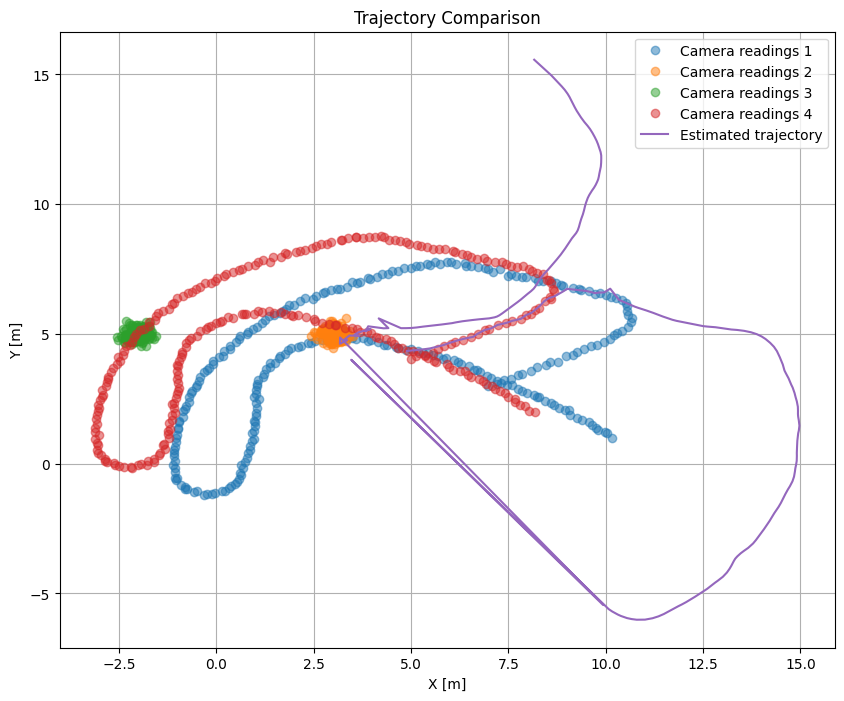

In [56]:
# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑

plt.figure(figsize=(10, 8))

trajectory = np.vstack(trajectory)

# 1. Camera readings (converted to world coordinates)
x_cam = camera_readings1[:, 0] * scene.camera_height / scene.focal_length
y_cam = -camera_readings1[:, 1] * scene.camera_height / scene.focal_length
plt.plot(x_cam, y_cam, 'o', label='Camera readings 1', alpha=0.5)

x_cam = camera_readings2[:, 0] * scene.camera_height / scene.focal_length
y_cam = -camera_readings2[:, 1] * scene.camera_height / scene.focal_length
plt.plot(x_cam, y_cam, 'o', label='Camera readings 2', alpha=0.5)

x_cam = camera_readings3[:, 0] * scene.camera_height / scene.focal_length
y_cam = -camera_readings3[:, 1] * scene.camera_height / scene.focal_length
plt.plot(x_cam, y_cam, 'o', label='Camera readings 3', alpha=0.5)

x_cam = camera_readings4[:, 0] * scene.camera_height / scene.focal_length
y_cam = -camera_readings4[:, 1] * scene.camera_height / scene.focal_length
plt.plot(x_cam, y_cam, 'o', label='Camera readings 4', alpha=0.5)

# 2. Trajectory states
plt.plot(trajectory[:, 0], trajectory[:, 1], '-', label='Estimated trajectory')

plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.legend()
plt.title('Trajectory Comparison')
plt.grid(True)
plt.show()

# 🛑🛑🛑🛑🛑 DO NOT TOUCH THIS 🛑🛑🛑🛑🛑